# ⚽ Football Match Outcome Prediction (Advanced)

This project predicts football match outcomes using the European Soccer Database.

### Objectives:
- Extract data from SQL database
- Perform feature engineering
- Build and compare machine learning models
- Evaluate performance and improve accuracy

### Pipeline:
SQL → Data Cleaning → Feature Engineering → Modeling → Evaluation

## 📦 Import Required Libraries

We import necessary libraries for:
- Data handling (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-learn)
- User Interaction (Streamlit)

In [29]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle   

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 🗄️ Connect to SQLite Database

We connect to the European Soccer Database to extract match-level data.

In [30]:
conn = sqlite3.connect("database.sqlite")

## 🔍 Extract Relevant Data Using SQL

We retrieve match data including:
- Home goals
- Away goals
- Team IDs
- Match date

In [31]:
query = """
SELECT 
    home_team_api_id,
    away_team_api_id,
    home_team_goal,
    away_team_goal
FROM Match
WHERE home_team_goal IS NOT NULL
AND away_team_goal IS NOT NULL
LIMIT 20000
"""

df = pd.read_sql(query, conn)
df.head()

,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,9987,9993,1,1
1,10000,9994,0,0
2,9984,8635,0,3
3,9991,9998,5,0
4,7947,9985,1,3


## 🧹 Data Cleaning

We remove missing values and ensure the dataset is clean for modeling.

In [32]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   home_team_api_id  20000 non-null  int64
 1   away_team_api_id  20000 non-null  int64
 2   home_team_goal    20000 non-null  int64
 3   away_team_goal    20000 non-null  int64
dtypes: int64(4)
memory usage: 625.1 KB


## ⚙️ Feature Engineering

We create meaningful features:
- Goal difference
- Total goals
- Match outcome (target variable)

In [33]:
def get_result(row):
    if row['home_team_goal'] > row['away_team_goal']:
        return 1
    elif row['home_team_goal'] < row['away_team_goal']:
        return 0
    else:
        return 2

df['Result'] = df.apply(get_result, axis=1)

## 📊 Exploratory Data Analysis (EDA)

We visualize the distribution of match outcomes and goal patterns.

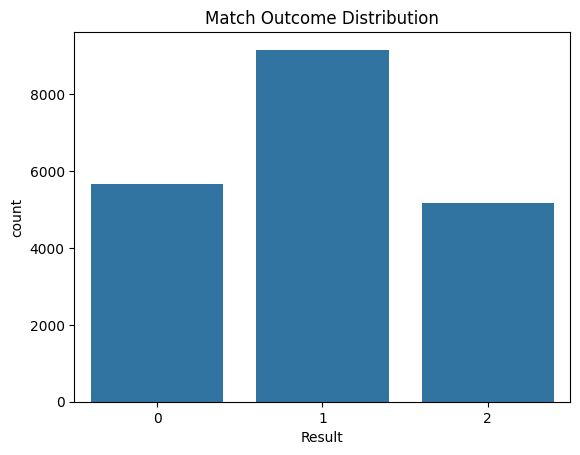

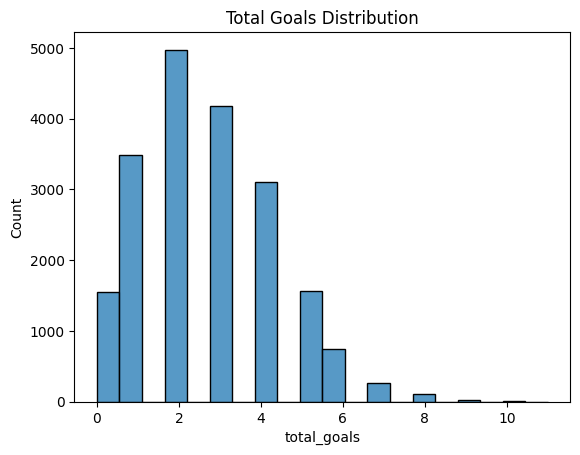

In [35]:
# Create new feature
df['total_goals'] = df['home_team_goal'] + df['away_team_goal']

# Plot 1
sns.countplot(x=df['Result'])
plt.title("Match Outcome Distribution")
plt.show()

# Plot 2
sns.histplot(df['total_goals'], bins=20)
plt.title("Total Goals Distribution")
plt.show()

## 🎯 Feature Selection

We select relevant features for prediction.

In [36]:
X = df[['home_team_api_id', 'away_team_api_id']]
y = df['Result']


## 🔀 Train-Test Split

We split the dataset into training and testing sets.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🤖 Model Training

We train a Random Forest model for classification.

In [38]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 📈 Model Evaluation

We evaluate the model using:
- Accuracy
- Classification Report
- Confusion Matrix

### Observations:
- The model achieves an accuracy of approximately **42%**
- This relatively low accuracy indicates that predicting match outcomes using only team IDs is challenging
- Football matches are influenced by many complex factors not captured in this model

### Conclusion:
- The model provides a baseline prediction
- Performance can be improved by adding more features such as:
  - Team form
  - Player statistics
  - Historical performance

Accuracy: 0.42625

Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.35      0.36      1130
           1       0.52      0.60      0.56      1804
           2       0.27      0.21      0.24      1066

    accuracy                           0.43      4000
   macro avg       0.39      0.39      0.38      4000
weighted avg       0.41      0.43      0.42      4000



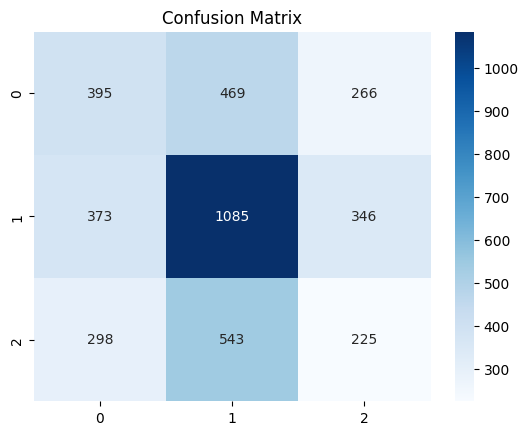

In [39]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## 💾 Save Model
We save the trained model for deployment.

In [40]:
pickle.dump(model, open("model.pkl", "wb"))

## 📛 Team Mapping
We create a mapping of team IDs to names for UI display.

In [41]:
team_query = "SELECT team_api_id, team_long_name FROM Team"
teams = pd.read_sql(team_query, conn)

team_dict = dict(zip(teams.team_api_id, teams.team_long_name))

# Save mapping
pickle.dump(team_dict, open("team_dict.pkl", "wb"))